# 00 - Machine Learning Basics

This notebook introduces five classical machine learning ideas that appear repeatedly in quantum machine learning (QML): linear regression, nonlinear binary classification, clustering, principal component analysis, and support vector machines.

The goal is not to use a high-level machine learning library. Every code cell uses only NumPy and Matplotlib from the existing `uv` project environment, and every code cell is self-contained: it imports what it needs, creates its own data, trains its own model, and draws its own visualization.

The examples are intentionally small. That makes the algorithms visible: you can inspect the loss, gradients, decision boundaries, assignments, principal directions, and margins directly.

## Common notation

A dataset is usually written as

$$
X = \begin{bmatrix} x_1^T \\ x_2^T \\ \cdots \\ x_n^T \end{bmatrix} \in \mathbb{R}^{n \times d},
\qquad
y = \begin{bmatrix} y_1 \\ y_2 \\ \cdots \\ y_n \end{bmatrix}.
$$

Here `n` is the number of examples and `d` is the number of features. A model produces predictions `y_hat`, and learning usually means choosing parameters that minimize an empirical loss:

$$
\min_\theta \; J(\theta)
\qquad \text{where} \qquad
J(\theta) = \frac{1}{n} \sum_{i=1}^n \ell(f_\theta(x_i), y_i).
$$

In QML, the same template often appears with a quantum circuit, a quantum kernel, or a quantum feature map playing the role of `f_theta` or `phi(x)`.

NumPy version: 2.2.6
Sample from the random generator: [ 0.001  0.299 -0.274 -0.891 -0.455]


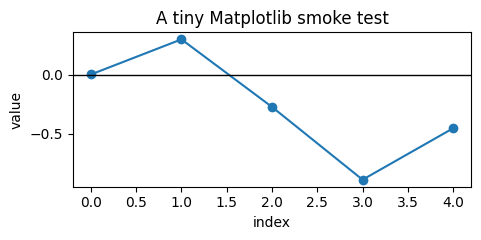

In [1]:
# Pseudo-code:
#   1. import numerical and plotting tools
#   2. create a reproducible random sample
#   3. print environment details
#   4. draw a small plot to verify rendering

# Self-contained environment check.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
sample = rng.normal(size=5)

print("NumPy version:", np.__version__)
print("Sample from the random generator:", np.round(sample, 3))

plt.figure(figsize=(5, 2.5))
plt.plot(sample, marker="o", color="tab:blue")
plt.axhline(0, color="black", linewidth=1)
plt.title("A tiny Matplotlib smoke test")
plt.xlabel("index")
plt.ylabel("value")
plt.tight_layout()
plt.show()


## 1. Linear regression

Linear regression predicts a real number from input features. With one feature, the model is the equation of a line:

$$
\hat y_i = w x_i + b.
$$

The most common loss is mean squared error (MSE):

$$
J(w,b) = \frac{1}{n}\sum_{i=1}^n (w x_i + b - y_i)^2.
$$

A convenient matrix form adds a column of ones to the input matrix:

$$
\tilde X = \begin{bmatrix} 1 & x_1 \\ 1 & x_2 \\ \cdots & \cdots \\ 1 & x_n \end{bmatrix},
\qquad
\theta = \begin{bmatrix} b \\ w \end{bmatrix}.
$$

Then predictions are `X_tilde @ theta`. The closed-form least-squares solution is

$$
\theta^* = (\tilde X^T \tilde X)^{-1}\tilde X^T y.
$$

In code we solve the linear system directly instead of explicitly forming the inverse, because numerical linear solves are more stable than matrix inversion.

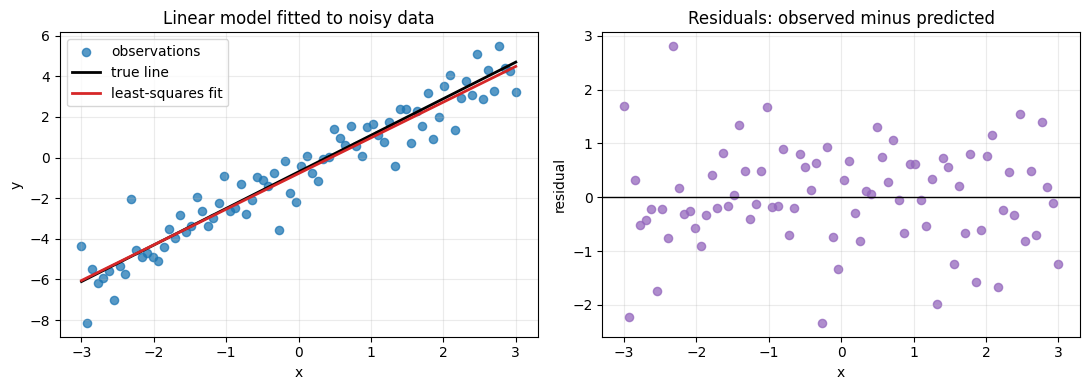

true slope=1.800, fitted slope=1.757
true intercept=-0.700, fitted intercept=-0.781
training MSE=0.850


In [ ]:
# Pseudo-code:
#   1. generate noisy linear data
#   2. solve the normal equation
#   3. compute residual diagnostics
#   4. plot the fitted line and residuals

# Linear regression by the closed-form normal equation.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(3)
n = 80
x = np.linspace(-3.0, 3.0, n)
true_w = 1.8
true_b = -0.7
noise = rng.normal(loc=0.0, scale=0.85, size=n)
y = true_w * x + true_b + noise

# Compute the least-squares solution by solving the normal equation.
# Construct the design matrix with a column of ones for the intercept term (bias).
# It works as follows: the first column of X_tilde is all ones, which allows us to solve for the intercept (b_hat)
# and the second column is the original x values, which allows us to solve for the slope (w_hat). 
# The normal equation is derived from setting the gradient of the mean squared error loss function to zero, 
# leading to a closed-form solution for the parameters that minimize the loss.
X_tilde = np.column_stack([np.ones_like(x), x])
# Solve for theta = [b_hat, w_hat] using the normal equation: theta = (X^T X)^{-1} X^T y
theta = np.linalg.solve(X_tilde.T @ X_tilde, X_tilde.T @ y)
# Initialize or update trainable model parameters.
b_hat, w_hat = theta
y_hat = X_tilde @ theta
residuals = y - y_hat
mse = np.mean(residuals**2)

line_x = np.linspace(x.min(), x.max(), 200)
line_y_true = true_w * line_x + true_b
line_y_fit = w_hat * line_x + b_hat

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(x, y, s=35, color="tab:blue", alpha=0.75, label="observations")
axes[0].plot(line_x, line_y_true, color="black", linewidth=2, label="true line")
axes[0].plot(line_x, line_y_fit, color="tab:red", linewidth=2, label="least-squares fit")
axes[0].set_title("Linear model fitted to noisy data")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].scatter(x, residuals, s=35, color="tab:purple", alpha=0.75)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Residuals: observed minus predicted")
axes[1].set_xlabel("x")
axes[1].set_ylabel("residual")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"true slope={true_w:.3f}, fitted slope={w_hat:.3f}")
print(f"true intercept={true_b:.3f}, fitted intercept={b_hat:.3f}")
print(f"training MSE={mse:.3f}")


### Gradient descent view

The same linear model can be learned iteratively. For

$$
J(w,b) = \frac{1}{n}\sum_{i=1}^n (w x_i + b - y_i)^2,
$$

the gradients are

$$
\frac{\partial J}{\partial w} = \frac{2}{n}\sum_{i=1}^n (w x_i + b - y_i)x_i,
\qquad
\frac{\partial J}{\partial b} = \frac{2}{n}\sum_{i=1}^n (w x_i + b - y_i).
$$

Gradient descent repeatedly moves in the negative gradient direction:

$$
w \leftarrow w - \eta \frac{\partial J}{\partial w},
\qquad
b \leftarrow b - \eta \frac{\partial J}{\partial b},
$$

where `eta` is the learning rate.

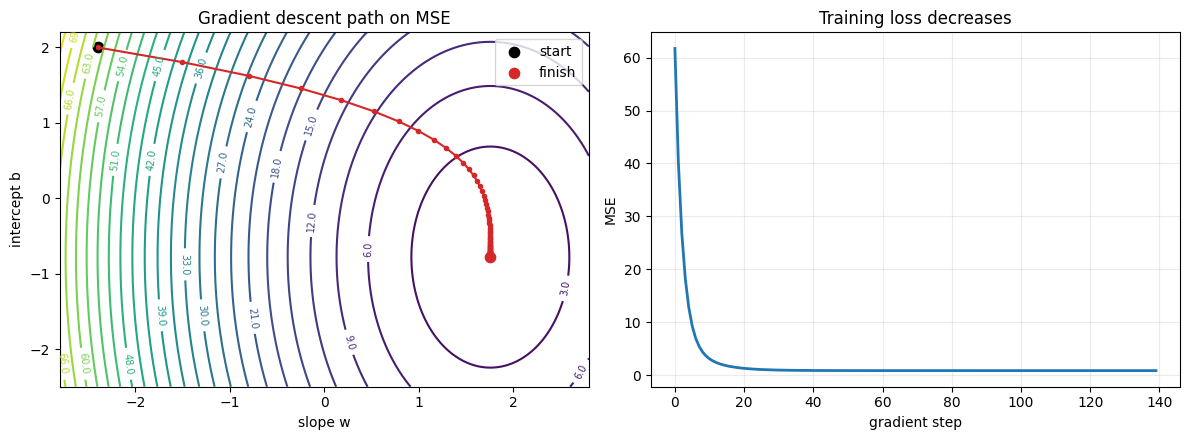

gradient descent slope=1.757, intercept=-0.781, final MSE=0.850


In [ ]:
# Pseudo-code:
#   1. generate the same regression dataset
#   2. initialize parameters and loss storage
#   3. repeat gradient updates
#   4. visualize the optimization path

# Linear regression by gradient descent, with a loss-surface visualization.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(3)
n = 80
x = np.linspace(-3.0, 3.0, n)
true_w = 1.8
true_b = -0.7
y = true_w * x + true_b + rng.normal(0.0, 0.85, size=n)

w = -2.4
# Initialize or update trainable model parameters.
b = 2.0
# Initialize or update trainable model parameters.
eta = 0.035 # Learning rate for gradient descent updates.
steps = 140 # Number of gradient descent steps to take.
path = [] # Storage for the optimization path, to be plotted later.
loss_history = [] # Storage for the training loss at each step, to be plotted later.

for step in range(steps):
    # Iterate through this part of the algorithm.
    prediction = w * x + b
    # Compute model outputs for the current data.
    error = prediction - y
    loss = np.mean(error**2)
    # Gradient of the mean squared error with respect to w and b:
    # mean because we want the average loss over the dataset, and the factor of 2 comes from the derivative of the square term.
    gradient_w = 2.0 * np.mean(error * x)
    # Compute a gradient signal for parameter updates.
    gradient_b = 2.0 * np.mean(error)
    # Compute a gradient signal for parameter updates.
    path.append([w, b, loss])
    # Save this value so the learning trajectory can be plotted.
    loss_history.append(loss)
    # Save this value so the learning trajectory can be plotted.
    w = w - eta * gradient_w
    # Initialize or update trainable model parameters.
    b = b - eta * gradient_b
    # Initialize or update trainable model parameters.

path = np.array(path)
w_grid = np.linspace(-2.8, 2.8, 140)
b_grid = np.linspace(-2.5, 2.2, 140)
W, B = np.meshgrid(w_grid, b_grid)
loss_grid = np.mean((W[..., None] * x + B[..., None] - y) ** 2, axis=2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

contours = axes[0].contour(W, B, loss_grid, levels=28, cmap="viridis")
axes[0].clabel(contours, inline=True, fontsize=7, fmt="%.1f")
axes[0].plot(path[:, 0], path[:, 1], color="tab:red", marker="o", markersize=3, linewidth=1.5)
axes[0].scatter(path[0, 0], path[0, 1], color="black", s=55, label="start")
axes[0].scatter(path[-1, 0], path[-1, 1], color="tab:red", s=55, label="finish")
axes[0].set_title("Gradient descent path on MSE")
axes[0].set_xlabel("slope w")
axes[0].set_ylabel("intercept b")
axes[0].legend()

axes[1].plot(loss_history, color="tab:blue", linewidth=2)
axes[1].set_title("Training loss decreases")
axes[1].set_xlabel("gradient step")
axes[1].set_ylabel("MSE")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"gradient descent slope={w:.3f}, intercept={b:.3f}, final MSE={loss_history[-1]:.3f}")


Linear regression is useful because it exposes the basic supervised-learning loop:

1. choose a model family,
2. choose a loss function,
3. optimize the parameters,
4. inspect residuals or errors.

More complicated models change the feature map, prediction rule, or optimizer, but the same structure remains.

## 2. Two moons classification

Classification predicts a discrete label. The two moons dataset is a standard toy example because a straight line cannot separate the classes well in the original two-dimensional input space.

For binary labels `y in {0, 1}`, logistic regression models the probability of class `1` as

$$
p(y=1 \mid x) = \sigma(z),
\qquad
z = \theta^T \phi(x),
\qquad
\sigma(z) = \frac{1}{1 + e^{-z}}.
$$

The function `phi(x)` is a feature map. A feature map is a function that transforms an input data point into a representation used by a model. A linear feature map gives a linear decision boundary. A nonlinear feature map can create a curved boundary in the original input space. Here we use the quadratic map

$$
\phi(x_1,x_2) = [1, x_1, x_2, x_1^2, x_1x_2, x_2^2]^T.
$$

the matrix $\Phi$ stacks those feature vectors row by row:

$$
\Phi =
\begin{bmatrix}
1 & x_{1,1} & x_{1,2} & x_{1,1}^2 & x_{1,1}x_{1,2} & x_{1,2}^2 \\
1 & x_{2,1} & x_{2,2} & x_{2,1}^2 & x_{2,1}x_{2,2} & x_{2,2}^2 \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
1 & x_{n,1} & x_{n,2} & x_{n,1}^2 & x_{n,1}x_{n,2} & x_{n,2}^2
\end{bmatrix}.
$$

So if there are \(n\) data points and 6 quadratic features, then:

$$
\Phi \in \mathbb{R}^{n \times 6}.
$$

The binary cross-entropy loss is

$$
J(\theta) = -\frac{1}{n}\sum_{i=1}^n
\left[y_i\log p_i + (1-y_i)\log(1-p_i)\right].
$$

The intuition: **binary cross-entropy punishes the model for assigning low probability to the correct class**.

For binary labels $y \in \{0,1\}$, the model predicts

$$
p_i = P(y_i = 1 \mid x_i).
$$

The binary cross-entropy loss is

$$
J(\theta) =
-\frac{1}{n}
\sum_{i=1}^n
\left[
y_i \log(p_i)
+
(1-y_i)\log(1-p_i)
\right].
$$

There are two cases.

If the true label is $y_i = 1$, then

$$
\ell_i = -\log(p_i).
$$

So the model is rewarded when $p_i$ is close to 1.

If the true label is $y_i = 0$, then

$$
\ell_i = -\log(1-p_i).
$$

So the model is rewarded when $p_i$ is close to 0.

The logarithm makes confident mistakes very expensive. For example, if the true label is 1:

$$
p_i = 0.9
\quad \Rightarrow \quad
-\log(0.9) \approx 0.105,
$$

but

$$
p_i = 0.01
\quad \Rightarrow \quad
-\log(0.01) \approx 4.605.
$$

So binary cross-entropy says:

> Do not just predict the right class. Assign high probability to the right class, and avoid being confidently wrong.

The $n$ in the formula is the number of training examples. We average over all examples to get one scalar loss.


Its gradient for the feature matrix `Phi` is. 

$$
\nabla_\theta J = \frac{1}{n}\Phi^T(p-y).
$$

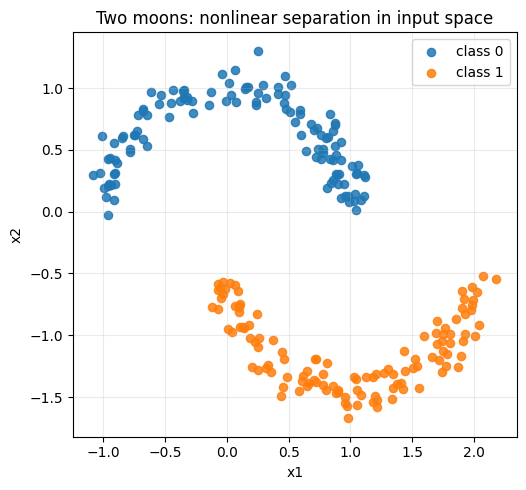

In [4]:
# Pseudo-code:
#   1. sample two half-circles
#   2. add noise and labels
#   3. plot the nonlinear classification data

# Generate and visualize a two moons classification dataset from scratch.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(11)
n_per_class = 120
angles_a = rng.uniform(0.0, np.pi, n_per_class)
angles_b = rng.uniform(0.0, np.pi, n_per_class)

moon_a = np.column_stack([np.cos(angles_a), np.sin(angles_a)])
moon_b = np.column_stack([1.0 - np.cos(angles_b), -np.sin(angles_b) - 0.45])
X = np.vstack([moon_a, moon_b])
X = X + rng.normal(0.0, 0.09, size=X.shape)
y = np.r_[np.zeros(n_per_class), np.ones(n_per_class)]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[y == 0, 0], X[y == 0, 1], s=35, color="tab:blue", label="class 0", alpha=0.85)
ax.scatter(X[y == 1, 0], X[y == 1, 1], s=35, color="tab:orange", label="class 1", alpha=0.85)
ax.set_title("Two moons: nonlinear separation in input space")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


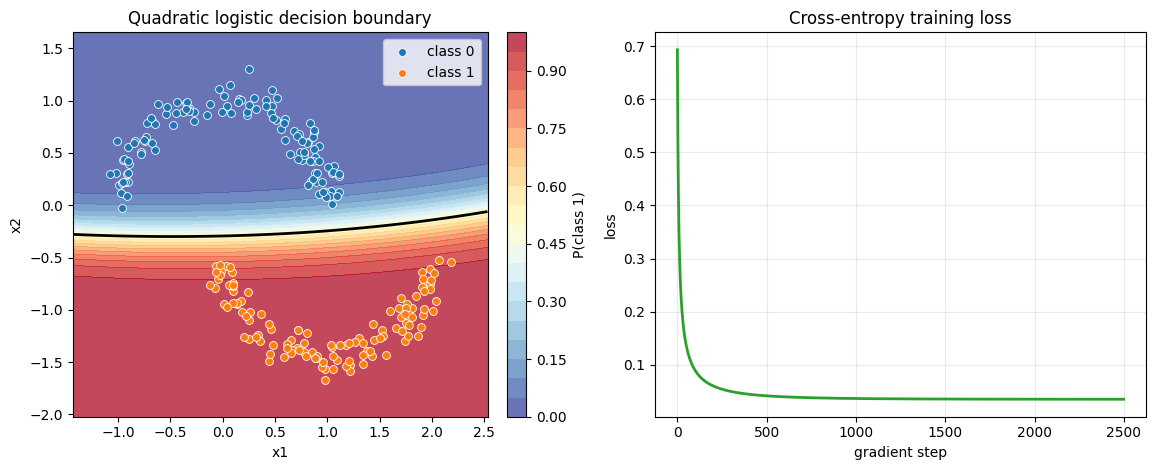

training accuracy=1.000
learned theta= [-0.106  0.301 -6.3    0.117  0.186 -0.012]


In [ ]:
# Pseudo-code:
#   1. generate and standardize two-moons data
#   2. build quadratic features
#   3. train logistic regression by gradient descent
#   4. plot probabilities, boundary, and loss

# Logistic classifier with a quadratic feature map, implemented from scratch.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(11)
n_per_class = 120
angles_a = rng.uniform(0.0, np.pi, n_per_class)
angles_b = rng.uniform(0.0, np.pi, n_per_class)
moon_a = np.column_stack([np.cos(angles_a), np.sin(angles_a)])
moon_b = np.column_stack([1.0 - np.cos(angles_b), -np.sin(angles_b) - 0.45])
X_raw = np.vstack([moon_a, moon_b]) + rng.normal(0.0, 0.09, size=(2 * n_per_class, 2))
y = np.r_[np.zeros(n_per_class), np.ones(n_per_class)]

feature_mean = X_raw.mean(axis=0)
feature_scale = X_raw.std(axis=0)
X = (X_raw - feature_mean) / feature_scale
x1 = X[:, 0]
x2 = X[:, 1]
Phi = np.column_stack([np.ones(len(X)), x1, x2, x1**2, x1 * x2, x2**2])

theta = np.zeros(Phi.shape[1])
# Initialize or update trainable model parameters.
eta = 0.25
l2 = 1e-3
loss_history = []

for step in range(2500):
    # Logit is the linear output of the model before applying the sigmoid function to get probabilities.
    logits = Phi @ theta
    # Compute probabilities using the logistic sigmoid function, with clipping for numerical stability.
    probabilities = 1.0 / (1.0 + np.exp(-np.clip(logits, -35.0, 35.0)))
    # Epsilon is added to the log function to prevent taking the log of zero, which can occur if probabilities are exactly 0 or 1 due to numerical precision issues. This ensures that the cross-entropy loss remains finite and stable during training.
    eps = 1e-12
    cross_entropy = -np.mean(y * np.log(probabilities + eps) + (1.0 - y) * np.log(1.0 - probabilities + eps))
    # Compute the training objective being minimized.
    regularization = 0.5 * l2 * np.sum(theta[1:] ** 2)
    loss_history.append(cross_entropy + regularization)
    # Save this value so the learning trajectory can be plotted.
    gradient = (Phi.T @ (probabilities - y)) / len(y)
    # Compute a gradient signal for parameter updates.
    gradient[1:] = gradient[1:] + l2 * theta[1:]
    # Compute a gradient signal for parameter updates.
    theta = theta - eta * gradient
    # Initialize or update trainable model parameters.

x_min, x_max = X_raw[:, 0].min() - 0.35, X_raw[:, 0].max() + 0.35
y_min, y_max = X_raw[:, 1].min() - 0.35, X_raw[:, 1].max() + 0.35
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 260), np.linspace(y_min, y_max, 260))
grid_raw = np.column_stack([xx.ravel(), yy.ravel()])
grid_scaled = (grid_raw - feature_mean) / feature_scale
g1 = grid_scaled[:, 0]
g2 = grid_scaled[:, 1]
GridPhi = np.column_stack([np.ones(len(grid_scaled)), g1, g2, g1**2, g1 * g2, g2**2])
grid_prob = 1.0 / (1.0 + np.exp(-np.clip(GridPhi @ theta, -35.0, 35.0)))
# Compute model outputs for the current data.
grid_prob = grid_prob.reshape(xx.shape)
# Compute model outputs for the current data.

train_prob = 1.0 / (1.0 + np.exp(-np.clip(Phi @ theta, -35.0, 35.0)))
# Compute model outputs for the current data.
train_pred = (train_prob >= 0.5).astype(float)
accuracy = np.mean(train_pred == y)
# Measure classification performance.

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

background = axes[0].contourf(xx, yy, grid_prob, levels=np.linspace(0, 1, 21), cmap="RdYlBu_r", alpha=0.75)
axes[0].contour(xx, yy, grid_prob, levels=[0.5], colors="black", linewidths=2)
axes[0].scatter(X_raw[y == 0, 0], X_raw[y == 0, 1], s=32, color="tab:blue", edgecolor="white", linewidth=0.6, label="class 0")
axes[0].scatter(X_raw[y == 1, 0], X_raw[y == 1, 1], s=32, color="tab:orange", edgecolor="white", linewidth=0.6, label="class 1")
axes[0].set_title("Quadratic logistic decision boundary")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_aspect("equal", adjustable="box")
axes[0].legend(loc="upper right")
fig.colorbar(background, ax=axes[0], fraction=0.046, pad=0.04, label="P(class 1)")

axes[1].plot(loss_history, color="tab:green", linewidth=2)
axes[1].set_title("Cross-entropy training loss")
axes[1].set_xlabel("gradient step")
axes[1].set_ylabel("loss")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"training accuracy={accuracy:.3f}")
print("learned theta=", np.round(theta, 3))


The important idea is the feature map. The classifier is linear in `phi(x)`, but the boundary in the original `(x1, x2)` plane is curved. This is the same conceptual move used in kernel methods and many QML models: map data into a feature space where a simple rule can become expressive.

## 3. Clustering

Clustering is unsupervised learning: there are inputs `X`, but no labels `y`. A simple clustering method is k-means.

Given `K` centroids `mu_1, ..., mu_K`, each point is assigned to its nearest centroid:

$$
c_i = \arg\min_{k \in \{1,\ldots,K\}} \|x_i - \mu_k\|_2^2.
$$

Then each centroid is updated to the mean of the points assigned to it:

$$
\mu_k \leftarrow \frac{1}{|C_k|}\sum_{i: c_i=k} x_i.
$$

K-means minimizes the within-cluster sum of squares:

$$
J(\mu_1,\ldots,\mu_K) = \sum_{i=1}^n \min_k \|x_i - \mu_k\|_2^2.
$$

The algorithm alternates between assignment and update steps until the assignments stop changing or the objective becomes stable.

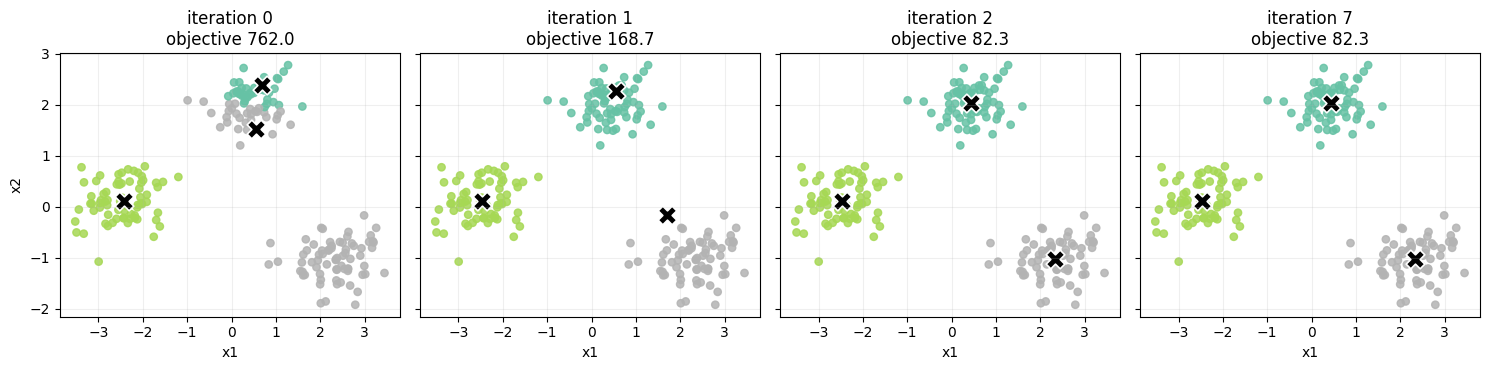

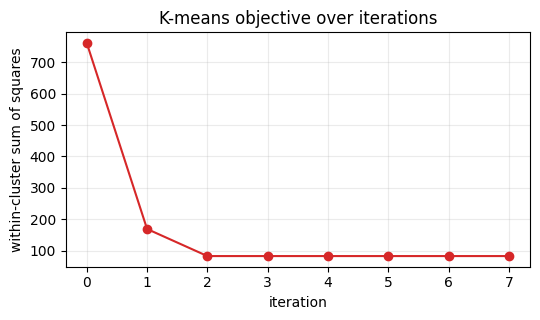

In [ ]:
# Pseudo-code:
#   1. generate unlabeled clustered data
#   2. initialize centroids
#   3. alternate assignment and centroid updates
#   4. plot snapshots and objective history

# K-means clustering from scratch, showing the first iterations.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(21)
centers = np.array([[-2.4, 0.1], [0.5, 2.1], [2.2, -1.1]])
points_per_cluster = 70
X = np.vstack([
    center + rng.normal(0.0, [0.55, 0.4], size=(points_per_cluster, 2))
    for center in centers
])
X = X[rng.permutation(len(X))]

K = 3
# Initialize K cluster centroids by randomly sampling K distinct points from the dataset.
centroids = X[rng.choice(len(X), size=K, replace=False)].copy()
snapshots = []
objective_history = []

for iteration in range(8):
    # Calculate the squared Euclidean distance from each point to each centroid.
    squared_distances = np.sum((X[:, None, :] - centroids[None, :, :]) ** 2, axis=2)
    labels = np.argmin(squared_distances, axis=1)
    objective = np.sum(squared_distances[np.arange(len(X)), labels])
    # Compute the training objective being minimized.
    objective_history.append(objective)
    # Save this value so the learning trajectory can be plotted.
    snapshots.append((iteration, centroids.copy(), labels.copy(), objective))
    # Save this value so the learning trajectory can be plotted.

    new_centroids = centroids.copy()
    for k in range(K):
        # Recompute the centroid of each cluster as the mean of the assigned points.
        assigned_points = X[labels == k]
        if len(assigned_points) > 0:
            # Handle this branch only when the condition is satisfied.
            new_centroids[k] = assigned_points.mean(axis=0)
    centroids = new_centroids

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharex=True, sharey=True)
for ax, index in zip(axes, [0, 1, 2, 7]):
    # Iterate through this part of the algorithm.
    iteration, shown_centroids, shown_labels, shown_objective = snapshots[index]
    # Compute the training objective being minimized.
    ax.scatter(X[:, 0], X[:, 1], c=shown_labels, cmap="Set2", s=28, alpha=0.85)
    ax.scatter(shown_centroids[:, 0], shown_centroids[:, 1], marker="X", s=180, c="black", edgecolor="white", linewidth=1.2)
    ax.set_title(f"iteration {iteration}\nobjective {shown_objective:.1f}")
    ax.set_xlabel("x1")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("x2")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5.5, 3.3))
plt.plot(objective_history, marker="o", color="tab:red")
plt.title("K-means objective over iterations")
plt.xlabel("iteration")
plt.ylabel("within-cluster sum of squares")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


K-means needs the number of clusters `K` in advance. A common diagnostic is the elbow curve: run k-means for several values of `K` and plot the best objective found for each. The objective always decreases as `K` increases, so the useful signal is where the improvement starts to flatten.

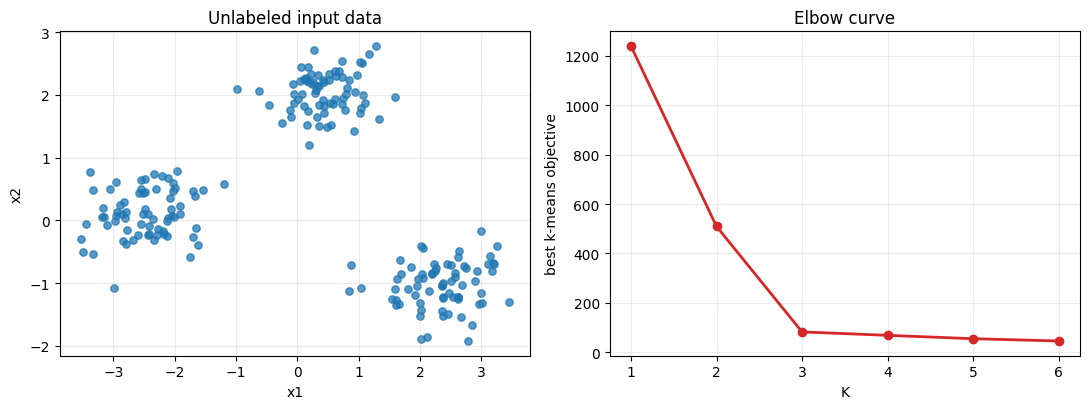

K=1: objective=1239.3
K=2: objective=509.3
K=3: objective=82.3
K=4: objective=68.4
K=5: objective=54.8
K=6: objective=45.5


In [7]:
# Pseudo-code:
#   1. generate clustered data
#   2. run k-means for several K values
#   3. keep the best restart for each K
#   4. plot the elbow curve

# Elbow curve for k-means, implemented with repeated random initializations.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(21)
centers = np.array([[-2.4, 0.1], [0.5, 2.1], [2.2, -1.1]])
points_per_cluster = 70
X = np.vstack([
    center + rng.normal(0.0, [0.55, 0.4], size=(points_per_cluster, 2))
    for center in centers
])
X = X[rng.permutation(len(X))]

k_values = np.arange(1, 7)
best_objectives = []

for K in k_values:
    # Iterate through this part of the algorithm.
    best_objective_for_k = np.inf
    # Compute the training objective being minimized.
    for restart in range(12):
        # Iterate through this part of the algorithm.
        centroids = X[rng.choice(len(X), size=K, replace=False)].copy()
        for iteration in range(20):
            # Iterate through this part of the algorithm.
            squared_distances = np.sum((X[:, None, :] - centroids[None, :, :]) ** 2, axis=2)
            labels = np.argmin(squared_distances, axis=1)
            new_centroids = centroids.copy()
            for k in range(K):
                # Iterate through this part of the algorithm.
                assigned_points = X[labels == k]
                if len(assigned_points) > 0:
                    # Handle this branch only when the condition is satisfied.
                    new_centroids[k] = assigned_points.mean(axis=0)
            shift = np.sqrt(np.sum((new_centroids - centroids) ** 2))
            centroids = new_centroids
            if shift < 1e-6:
                # Handle this branch only when the condition is satisfied.
                break
                # Stop this loop once convergence is reached.
        squared_distances = np.sum((X[:, None, :] - centroids[None, :, :]) ** 2, axis=2)
        labels = np.argmin(squared_distances, axis=1)
        objective = np.sum(squared_distances[np.arange(len(X)), labels])
        # Compute the training objective being minimized.
        best_objective_for_k = min(best_objective_for_k, objective)
        # Compute the training objective being minimized.
    best_objectives.append(best_objective_for_k)
    # Save this value so the learning trajectory can be plotted.

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].scatter(X[:, 0], X[:, 1], s=28, color="tab:blue", alpha=0.75)
axes[0].set_title("Unlabeled input data")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].grid(alpha=0.25)

axes[1].plot(k_values, best_objectives, marker="o", color="tab:red", linewidth=2)
axes[1].set_title("Elbow curve")
axes[1].set_xlabel("K")
axes[1].set_ylabel("best k-means objective")
axes[1].set_xticks(k_values)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

for K, objective in zip(k_values, best_objectives):
    # Iterate through this part of the algorithm.
    print(f"K={K}: objective={objective:.1f}")


Clustering does not know the true classes. It only sees geometry. This is why feature scaling, distance choice, and the representation of the data matter so much. K-means works well when clusters are roughly compact and spherical, but it can fail on elongated, nested, or density-shaped clusters.

## 4. Principal component analysis

Principal component analysis (PCA) is an unsupervised method for finding directions of largest variance in a dataset. It is often used for visualization, compression, denoising, and preprocessing.

PCA starts by centering the data:

$$
X_c = X - \mu,
\qquad
\mu = \frac{1}{n}\sum_{i=1}^n x_i.
$$

Then it computes the empirical covariance matrix:

$$
S = \frac{1}{n-1}X_c^T X_c.
$$

The first principal component is the unit direction with maximum projected variance:

$$
v_1 = \arg\max_{\|v\|_2=1} v^T S v.
$$

The solution is the eigenvector of \(S\) with the largest eigenvalue. More generally,

$$
S v_j = \lambda_j v_j,
\qquad
\lambda_1 \ge \lambda_2 \ge \cdots \ge 0.
$$

Projecting onto the first `k` principal components gives the low-dimensional coordinates

$$
Z = X_c V_k,
$$

and reconstructing back to the original space gives

$$
\hat X = ZV_k^T + \mu.
$$

The explained variance ratio tells us how much total variance is captured by each component:

$$
r_j = \frac{\lambda_j}{\sum_m \lambda_m}.
$$


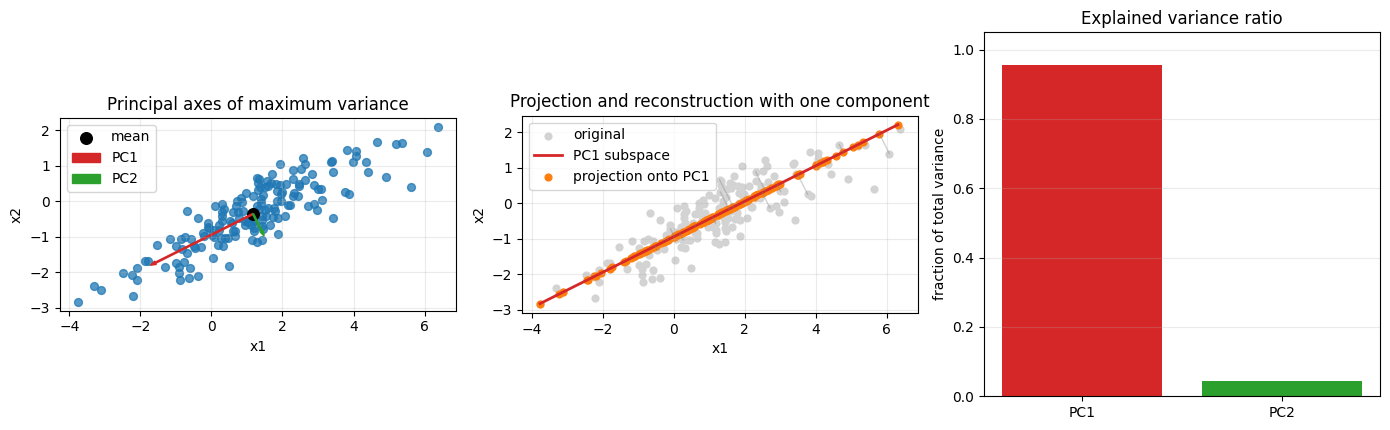

covariance matrix:
[[3.296 1.554]
 [1.554 0.965]]
eigenvalues: [4.073 0.188]
explained variance ratio: [0.956 0.044]
PC1-only reconstruction RMSE=0.433


In [1]:
# Pseudo-code:
#   1. generate correlated two-dimensional data
#   2. center data and compute covariance
#   3. eigendecompose covariance to find principal axes
#   4. project to PC coordinates and reconstruct from PC1
#   5. visualize axes, projection, and explained variance

# PCA from scratch on a correlated two-dimensional dataset.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(52)
n = 160
mean = np.array([1.0, -0.4])
primary_direction = np.array([0.88, 0.47])
secondary_direction = np.array([-0.47, 0.88])
latent = rng.normal(0.0, 2.1, size=n)
noise = rng.normal(0.0, 0.45, size=n)
X = mean + latent[:, None] * primary_direction + noise[:, None] * secondary_direction

X_centered = X - X.mean(axis=0)
# Center the data so PCA captures variance, not the absolute location.
covariance = (X_centered.T @ X_centered) / (len(X_centered) - 1)
# Estimate the feature covariance matrix from centered data.
eigenvalues, eigenvectors = np.linalg.eigh(covariance)
# Diagonalize covariance; eigenvectors are candidate principal axes.
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]
# Sort components so PC1 captures the largest variance.

scores = X_centered @ eigenvectors
# Project each point into principal-component coordinates.
explained_ratio = eigenvalues / eigenvalues.sum()
# Measure the fraction of variance captured by each PC.
reconstruction_pc1 = scores[:, :1] @ eigenvectors[:, :1].T + X.mean(axis=0)
# Reconstruct data using only the first principal component.
reconstruction_error = np.sqrt(np.mean(np.sum((X - reconstruction_pc1) ** 2, axis=1)))
# Quantify the information lost by dropping PC2.

pc1_line = X.mean(axis=0) + np.outer(np.linspace(scores[:, 0].min(), scores[:, 0].max(), 80), eigenvectors[:, 0])
projected_pc1 = scores[:, :1] @ eigenvectors[:, :1].T + X.mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))

axes[0].scatter(X[:, 0], X[:, 1], s=32, color="tab:blue", alpha=0.75)
axes[0].scatter(*X.mean(axis=0), color="black", s=70, label="mean")
for scale, vector, color, label in [
    (np.sqrt(eigenvalues[0]) * 1.6, eigenvectors[:, 0], "tab:red", "PC1"),
    (np.sqrt(eigenvalues[1]) * 1.6, eigenvectors[:, 1], "tab:green", "PC2"),
]:
    axes[0].arrow(
        X.mean(axis=0)[0],
        X.mean(axis=0)[1],
        scale * vector[0],
        scale * vector[1],
        width=0.035,
        color=color,
        length_includes_head=True,
        label=label,
    )
axes[0].set_title("Principal axes of maximum variance")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].scatter(X[:, 0], X[:, 1], s=24, color="lightgray", label="original")
axes[1].plot(pc1_line[:, 0], pc1_line[:, 1], color="tab:red", linewidth=2, label="PC1 subspace")
axes[1].scatter(projected_pc1[:, 0], projected_pc1[:, 1], s=24, color="tab:orange", label="projection onto PC1")
for original, projected in zip(X[::12], projected_pc1[::12]):
    axes[1].plot([original[0], projected[0]], [original[1], projected[1]], color="gray", alpha=0.35, linewidth=1)
axes[1].set_title("Projection and reconstruction with one component")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].set_aspect("equal", adjustable="box")
axes[1].grid(alpha=0.25)
axes[1].legend()

axes[2].bar(["PC1", "PC2"], explained_ratio, color=["tab:red", "tab:green"])
axes[2].set_ylim(0, 1.05)
axes[2].set_title("Explained variance ratio")
axes[2].set_ylabel("fraction of total variance")
axes[2].grid(alpha=0.25, axis="y")

plt.tight_layout()
plt.show()

print("covariance matrix:")
print(np.round(covariance, 3))
print("eigenvalues:", np.round(eigenvalues, 3))
print("explained variance ratio:", np.round(explained_ratio, 3))
print(f"PC1-only reconstruction RMSE={reconstruction_error:.3f}")


## 5. Support vector machines

A support vector machine (SVM) is a margin-based classifier. For labels `y_i in {-1, +1}` and a linear score

$$
f(x) = w^T x + b,
$$

the signed margin of example `i` is

$$
m_i = y_i f(x_i).
$$

Correct points have `m_i > 0`. Points outside the margin band have `m_i >= 1`. The hinge loss penalizes margin violations:

$$
\ell_i = \max(0, 1 - y_i(w^T x_i + b)).
$$

A soft-margin linear SVM minimizes

$$
J(w,b) = \frac{\lambda}{2}\|w\|_2^2 + \frac{1}{n}\sum_{i=1}^n \max(0, 1 - y_i(w^T x_i + b)).
$$

The regularization term prefers a wider margin. The hinge term allows mistakes or near-margin points when the data are not perfectly separable.

The support vectors are the examples closest to the decision boundary. In a trained linear SVM, they satisfy approximately

$$
y_i(w^T x_i + b) \le 1.
$$

Kernel SVMs replace dot products with a kernel

$$
K(x,z) = \phi(x)^T\phi(z),
$$

which allows a linear separator in feature space to become a nonlinear separator in input space. This is one of the main classical ideas behind quantum kernel methods.

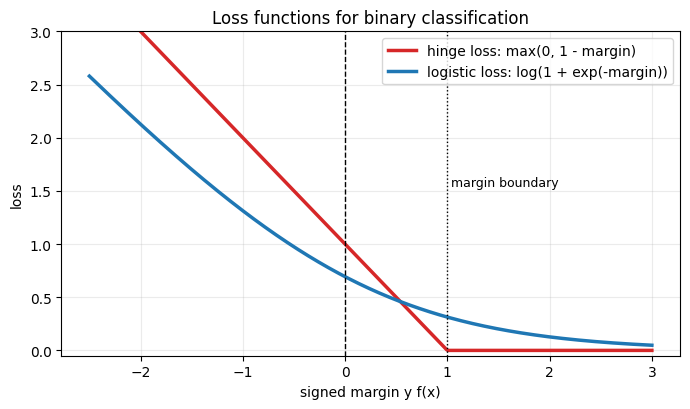

In [2]:
# Pseudo-code:
#   1. create signed-margin values
#   2. evaluate hinge and logistic losses
#   3. compare loss shapes visually

# Hinge loss compared with logistic loss as a function of signed margin y*f(x).
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt

margin = np.linspace(-2.5, 3.0, 500)
hinge_loss = np.maximum(0.0, 1.0 - margin)
logistic_loss = np.logaddexp(0.0, -margin)

plt.figure(figsize=(7, 4.2))
plt.plot(margin, hinge_loss, color="tab:red", linewidth=2.5, label="hinge loss: max(0, 1 - margin)")
plt.plot(margin, logistic_loss, color="tab:blue", linewidth=2.5, label="logistic loss: log(1 + exp(-margin))")
plt.axvline(0, color="black", linewidth=1, linestyle="--")
plt.axvline(1, color="black", linewidth=1, linestyle=":")
plt.text(1.04, 1.55, "margin boundary", fontsize=9)
plt.title("Loss functions for binary classification")
plt.xlabel("signed margin y f(x)")
plt.ylabel("loss")
plt.ylim(-0.05, 3.0)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


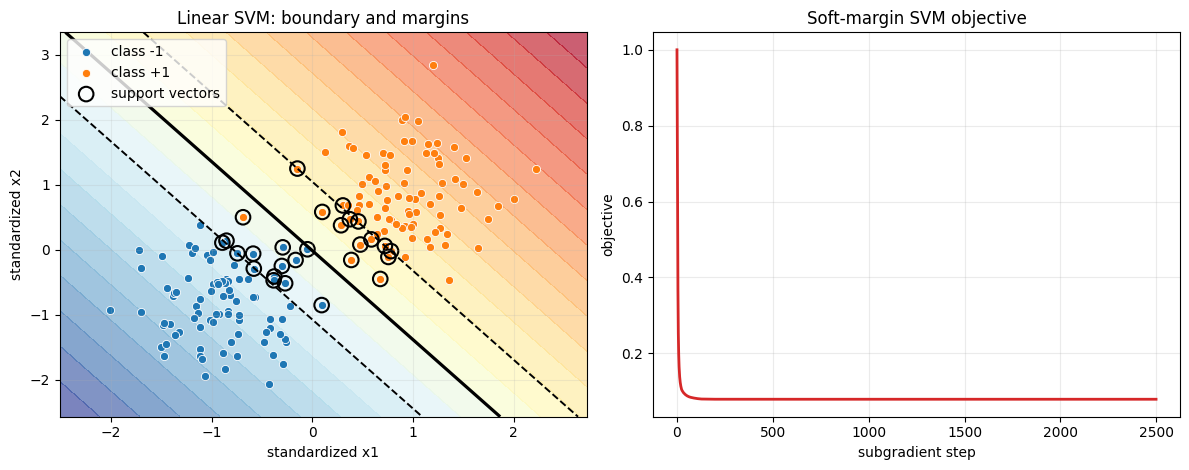

training accuracy=0.994
number of support-vector-like points=27 out of 180
w= [1.293 0.943] b= 0.015


In [ ]:
# Pseudo-code:
#   1. generate two Gaussian classes
#   2. train a soft-margin SVM by subgradient descent
#   3. identify margin-supporting points
#   4. plot boundary, margins, and loss

# Linear soft-margin SVM trained from scratch with subgradient descent.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(41)
n_per_class = 90
class_neg = rng.normal(loc=[-1.4, -0.7], scale=[0.75, 0.55], size=(n_per_class, 2))
class_pos = rng.normal(loc=[1.3, 0.75], scale=[0.75, 0.55], size=(n_per_class, 2))
X_raw = np.vstack([class_neg, class_pos])
y = np.r_[-np.ones(n_per_class), np.ones(n_per_class)]

feature_mean = X_raw.mean(axis=0)
feature_scale = X_raw.std(axis=0)
X = (X_raw - feature_mean) / feature_scale

w = np.zeros(2)
# Initialize or update trainable model parameters.
b = 0.0
# Initialize or update trainable model parameters.
regularization_strength = 0.03
initial_eta = 0.09
steps = 2500
loss_history = []

for step in range(steps):
    # Score is the raw output of the linear model before applying the sign function to get predictions.
    scores = X @ w + b
    # Compute model outputs for the current data.
    margins = y * scores
    active = margins < 1.0
    hinge = np.maximum(0.0, 1.0 - margins)
    # Compute the training objective being minimized.
    objective = 0.5 * regularization_strength * np.sum(w**2) + np.mean(hinge)
    # Compute the training objective being minimized.
    loss_history.append(objective)
    # Save this value so the learning trajectory can be plotted.

    gradient_w = regularization_strength * w
    # Compute a gradient signal for parameter updates.
    gradient_b = 0.0
    # Compute a gradient signal for parameter updates.
    if np.any(active):
        # Handle this branch only when the condition is satisfied.
        gradient_w = gradient_w - (y[active, None] * X[active]).sum(axis=0) / len(X)
        # Compute a gradient signal for parameter updates.
        gradient_b = gradient_b - y[active].sum() / len(X)
        # Compute a gradient signal for parameter updates.
    eta = initial_eta / np.sqrt(1.0 + 0.002 * step)
    w = w - eta * gradient_w
    # Initialize or update trainable model parameters.
    b = b - eta * gradient_b
    # Initialize or update trainable model parameters.

scores = X @ w + b
# Compute model outputs for the current data.
margins = y * scores
support_mask = margins <= 1.05
prediction = np.where(scores >= 0.0, 1.0, -1.0)
# Compute model outputs for the current data.
accuracy = np.mean(prediction == y)
# Measure classification performance.

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 260), np.linspace(y_min, y_max, 260))
grid = np.column_stack([xx.ravel(), yy.ravel()])
grid_scores = (grid @ w + b).reshape(xx.shape)
# Compute model outputs for the current data.

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].contourf(xx, yy, grid_scores, levels=np.linspace(grid_scores.min(), grid_scores.max(), 25), cmap="RdYlBu_r", alpha=0.65)
axes[0].contour(xx, yy, grid_scores, levels=[-1.0, 0.0, 1.0], colors=["black", "black", "black"], linestyles=["--", "-", "--"], linewidths=[1.4, 2.3, 1.4])
axes[0].scatter(X[y == -1, 0], X[y == -1, 1], s=35, color="tab:blue", edgecolor="white", linewidth=0.6, label="class -1")
axes[0].scatter(X[y == 1, 0], X[y == 1, 1], s=35, color="tab:orange", edgecolor="white", linewidth=0.6, label="class +1")
axes[0].scatter(X[support_mask, 0], X[support_mask, 1], s=110, facecolors="none", edgecolors="black", linewidths=1.5, label="support vectors")
axes[0].set_title("Linear SVM: boundary and margins")
axes[0].set_xlabel("standardized x1")
axes[0].set_ylabel("standardized x2")
axes[0].legend(loc="upper left")
axes[0].grid(alpha=0.2)

axes[1].plot(loss_history, color="tab:red", linewidth=2)
axes[1].set_title("Soft-margin SVM objective")
axes[1].set_xlabel("subgradient step")
axes[1].set_ylabel("objective")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"training accuracy={accuracy:.3f}")
print(f"number of support-vector-like points={support_mask.sum()} out of {len(X)}")
print("w=", np.round(w, 3), "b=", round(float(b), 3))


## Summary

The five examples share the same computational pattern: define a representation, define an objective or criterion, and optimize or iterate until the model explains the data well enough.

| Topic | Inputs | Target | Objective | Main visual idea |
|---|---:|---:|---|---|
| Linear regression | features | real values | mean squared error | fitted line and residuals |
| Two moons classification | features | class labels | cross-entropy | nonlinear decision boundary |
| K-means clustering | features | none | within-cluster squared distance | moving centroids |
| PCA | features | none | maximum projected variance | principal axes and low-dimensional projection |
| Linear SVM | features | class labels | margin plus hinge loss | boundary, margins, support vectors |

These basics are especially useful before QML because quantum models often reuse the same outer loop. What changes is the representation: a quantum feature map, a variational circuit, or a quantum kernel may replace the simple classical feature maps used here.

## Suggested experiments

1. Increase the noise in the linear regression data and watch the fitted line and residuals change.
2. Remove the quadratic terms from the two moons feature map and compare the decision boundary.
3. Change `K` in k-means to values that are too small or too large.
4. Increase the noise perpendicular to the PCA direction and watch the explained variance ratio change.
5. Increase the SVM regularization strength and observe how the margin and support vectors move.
6. Replace a handcrafted feature map with a new one and inspect whether optimization becomes easier or harder.